In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.0 MB/s eta 0:00:52
   ---------------------------------------- 1.0/101.7 MB 2.1 MB/s eta 0:00:49
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:48
    --------------------------------------- 2.1/101.7 MB 2.4 MB/s eta 0:00:43
   - -------------------------------------- 2.9/101.7 MB 2.7 MB/s eta 0:00:38
   - -------------------------------------- 4.2/101.7 MB 3.2 MB/s eta 0:00:31
   -- ------------------------------------- 5.2/101.7 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 6.6/101.7 MB 3.8 MB/s eta 0:00:26
   --- ------------------------------------ 7.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.2/101.7 MB 4.2 MB/s eta 0:00:23
   ---- ----------------------------------- 10.5/101.7 MB 4.4 MB/s eta 0:00:21

In [2]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------------------------- -- 524.3/555.9 kB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 555.9/555.9 kB 3.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [3]:
import pandas as pd, numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import shap

rfm    = pd.read_csv("data/processed/rfm_features.csv")
churn  = pd.read_csv("data/raw/churn_labels.csv")
sales  = pd.read_csv("data/processed/sales_cleaned.csv", parse_dates=['InvoiceDate'])

# Build behavioral signals beyond RFM
recent = sales[sales['InvoiceDate'] >= sales['InvoiceDate'].max() - pd.Timedelta(days=90)]
recent_agg = recent.groupby('CustomerID').agg(
    recent_orders =('Invoice','nunique'),
    recent_spend  =('TotalPrice','sum'),
    recent_aov    =('TotalPrice','mean')
).reset_index()
recent_agg['CustomerID'] = recent_agg['CustomerID'].astype(str)

rfm['CustomerID']   = rfm['CustomerID'].astype(str)
churn['CustomerID'] = churn['CustomerID'].astype(str)

df = rfm.merge(recent_agg, on='CustomerID', how='left').fillna(0)
df = df.merge(churn[['CustomerID','Churned']], on='CustomerID')

# IMPORTANT: drop DaysSinceLast (definition leakage with the target)
feat_cols = ['Recency','Frequency','Monetary','AOV','UniqueProducts','UniqueCategories',
             'Tenure','AvgQty','recent_orders','recent_spend','recent_aov',
             'R_Score','F_Score','M_Score']
# encode categoricals
for c in ['AgeGroup','Gender','LoyaltyTier','PreferredChannel','Country']:
    df[c] = df[c].astype('category').cat.codes
    feat_cols.append(c)

X, y = df[feat_cols], df['Churned']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_tr):,}  Test: {len(X_te):,}  Churn rate: {y.mean():.1%}")

Train: 6,056  Test: 1,515  Churn rate: 52.9%


In [4]:
# ===== CELL 2: Train XGBoost Churn Model =====

model = xgb.XGBClassifier(

    n_estimators=400,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.85,

    colsample_bytree=0.85,

    scale_pos_weight=(y_tr == 0).sum() /

                       (y_tr == 1).sum(),

    eval_metric='auc',

    random_state=42

)

# ===== Train Model =====

model.fit(

    X_tr,

    y_tr,

    eval_set=[(X_te, y_te)],

    verbose=False

)

# ===== Predict Probabilities =====

proba = model.predict_proba(X_te)[:, 1]

# ===== Calculate AUC =====

auc = roc_auc_score(

    y_te,

    proba

)

# ===== Precision @ Top 20% =====

threshold = np.percentile(

    proba,

    80

)

top20_pred = (

    proba >= threshold

).astype(int)

p_top20 = (

    top20_pred[y_te == 1].sum()

    /

    max(top20_pred.sum(), 1)

)

# ===== Print Results =====

print("=" * 60)

print("DAY 9 — CHURN PREDICTION RESULTS")

print("=" * 60)

print(f"🎯 AUC-ROC            : {auc:.4f}")

print(f"🎯 Precision@Top20%  : {p_top20:.4f}")

print("\n")

print(

    classification_report(

        y_te,

        model.predict(X_te)

    )

)

DAY 9 — CHURN PREDICTION RESULTS
🎯 AUC-ROC            : 0.9423
🎯 Precision@Top20%  : 0.9439


              precision    recall  f1-score   support

           0       0.95      0.92      0.93       714
           1       0.93      0.95      0.94       801

    accuracy                           0.94      1515
   macro avg       0.94      0.94      0.94      1515
weighted avg       0.94      0.94      0.94      1515



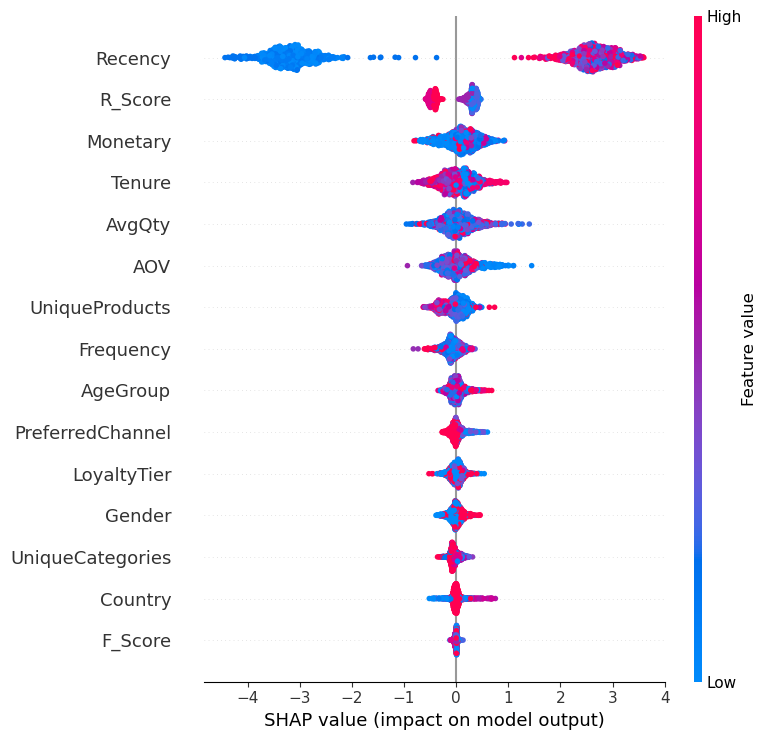

In [5]:
import matplotlib.pyplot as plt

sample_data = X_te.sample(

    min(2000, len(X_te)),

    random_state=42

)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(sample_data)

shap.summary_plot(

    shap_values,

    sample_data,

    show=False,

    max_display=15

)

plt.tight_layout()

plt.savefig(

    'reports/day9_shap_summary.png',

    dpi=120,

    bbox_inches='tight'

)

plt.show()